# DAY 5: CENTRALIZED BASELINE MODEL TRAINING
# EfficientNetB0 with Transfer Learning

In [ ]:
# ============================================
# CELL 1: Setup Environment
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/FL-Pneumonia-Detection'
os.chdir(PROJECT_ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import json
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Mounted at /content/drive
✅ Device: cuda
   GPU: Tesla T4
   Memory: 15.83 GB


In [ ]:
# ============================================
# CELL 2: Initialize WandB
# ============================================
wandb.login()

wandb.init(
    project="fl-pneumonia-detection",
    name="day5-centralized-baseline-efficientnet",
    config={
        "phase": "baseline_training",
        "week": 1,
        "day": 5,
        "model": "EfficientNetB0",
        "image_size": 224,
        "batch_size": 64,  # EfficientNet allows larger batch
        "epochs": 15,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "scheduler": "ReduceLROnPlateau",
        "early_stopping_patience": 5
    }
)

config = wandb.config
print("✅ WandB initialized!")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chiwa-vw (chiwa-vw-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB initialized!


In [ ]:
# ============================================
# CELL 3: Load Preprocessing Utilities
# ============================================
# Import our saved utilities from Day 3
import sys
sys.path.append(PROJECT_ROOT)

from utils.preprocessing import (
    ChestXrayDataset,
    get_train_transforms,
    get_val_test_transforms,
    load_class_weights
)

# Paths
DATA_RAW = os.path.join(PROJECT_ROOT, 'data/raw')
CHEST_XRAY_DIR = os.path.join(DATA_RAW, 'chest_xray', 'chest_xray')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

os.makedirs(MODELS_DIR, exist_ok=True)

print(f"✅ Paths configured")
print(f"   Data: {CHEST_XRAY_DIR}")
print(f"   Models: {MODELS_DIR}")


✅ Paths configured
   Data: /content/drive/MyDrive/FL-Pneumonia-Detection/data/raw/chest_xray/chest_xray
   Models: /content/drive/MyDrive/FL-Pneumonia-Detection/models


In [ ]:
# ============================================
# CELL 4: Create Datasets & DataLoaders
# ============================================
# Create datasets
train_dataset = ChestXrayDataset(
    data_dir=CHEST_XRAY_DIR,
    split='train',
    transform=get_train_transforms()
)

val_dataset = ChestXrayDataset(
    data_dir=CHEST_XRAY_DIR,
    split='val',
    transform=get_val_test_transforms()
)

test_dataset = ChestXrayDataset(
    data_dir=CHEST_XRAY_DIR,
    split='test',
    transform=get_val_test_transforms()
)

# Create dataloaders with larger batch size for EfficientNet
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\n📊 Dataset Summary:")
print(f"   Train: {len(train_dataset)} images ({len(train_loader)} batches)")
print(f"   Val: {len(val_dataset)} images ({len(val_loader)} batches)")
print(f"   Test: {len(test_dataset)} images ({len(test_loader)} batches)")



📊 Dataset Summary:
   Train: 5216 images (82 batches)
   Val: 16 images (1 batches)
   Test: 624 images (10 batches)


In [ ]:
# ============================================
# CELL 5: Build EfficientNetB0 Model
# ============================================
def create_efficientnet_model(num_classes=2, pretrained=True):
    """
    Create EfficientNetB0 with custom classifier
    """
    # Load pretrained EfficientNetB0
    model = models.efficientnet_b0(pretrained=pretrained)

    # Freeze early layers (optional - can unfreeze for fine-tuning)
    # for param in model.features.parameters():
    #     param.requires_grad = False

    # Replace classifier
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(num_features, num_classes)
    )

    return model

# Create model
model = create_efficientnet_model(num_classes=2, pretrained=True)
model = model.to(device)

print("✅ EfficientNetB0 Model Created!")
print(f"\n📐 Model Architecture:")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 167MB/s]


✅ EfficientNetB0 Model Created!

📐 Model Architecture:
   Total parameters: 4,010,110
   Trainable parameters: 4,010,110


In [ ]:
# ============================================
# CELL 6: Setup Training Components
# ============================================
# Load class weights for imbalanced data
class_weights = load_class_weights()
class_weights = class_weights.to(device)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer - Adam works well with EfficientNet
optimizer = optim.Adam(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=1e-4  # L2 regularization
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("✅ Training components configured!")
print(f"   Loss: CrossEntropyLoss with class weights")
print(f"   Optimizer: Adam (lr={config.learning_rate})")
print(f"   Scheduler: ReduceLROnPlateau")
print(f"   Class weights: NORMAL={class_weights[0]:.3f}, PNEUMONIA={class_weights[1]:.3f}")

✅ Training components configured!
   Loss: CrossEntropyLoss with class weights
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau
   Class weights: NORMAL=1.945, PNEUMONIA=0.673


In [ ]:
# ============================================
# CELL 7: Training & Validation Functions
# ============================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate model"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Get predictions and probabilities
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of pneumonia

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

print("✅ Training functions defined!")

✅ Training functions defined!


In [ ]:
# ============================================
# CELL 8: Training Loop with Early Stopping
# ============================================
def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs, device, patience=5):
    """
    Complete training loop with early stopping
    """
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    print("\n🚀 Starting Training...")
    print("="*60)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 60)

        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Validate
        val_loss, val_acc, _, _, _ = validate(
            model, val_loader, criterion, device
        )

        # Update scheduler
        scheduler.step(val_loss)

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print metrics
        print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Log to WandB
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'learning_rate': optimizer.param_groups[0]['lr']
        })

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            patience_counter = 0

            # Save checkpoint
            checkpoint_path = os.path.join(MODELS_DIR, 'best_centralized_model.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_acc': val_acc,
            }, checkpoint_path)

            print(f"✅ New best model saved! (Val Acc: {val_acc:.4f})")
        else:
            patience_counter += 1
            print(f"⏳ Patience: {patience_counter}/{patience}")

        # Early stopping
        if patience_counter >= patience:
            print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
            break

    print("\n" + "="*60)
    print("✅ Training Complete!")
    print(f"   Best Val Accuracy: {best_val_acc:.4f}")
    print(f"   Best Val Loss: {best_val_loss:.4f}")

    return history

# Train the model
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=config.epochs,
    device=device,
    patience=config.early_stopping_patience
)



🚀 Starting Training...

Epoch 1/15
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:07<00:00,  7.25s/it]



Train Loss: 0.1623 | Train Acc: 0.9312
Val Loss: 0.4090 | Val Acc: 0.8125
✅ New best model saved! (Val Acc: 0.8125)

Epoch 2/15
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.30it/s]



Train Loss: 0.0848 | Train Acc: 0.9674
Val Loss: 0.0630 | Val Acc: 1.0000
✅ New best model saved! (Val Acc: 1.0000)

Epoch 3/15
------------------------------------------------------------


...


Train Loss: 0.0497 | Train Acc: 0.9806
Val Loss: 0.2562 | Val Acc: 0.9375
⏳ Patience: 3/5

Epoch 6/15
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.39it/s]



Train Loss: 0.0363 | Train Acc: 0.9875
Val Loss: 0.0165 | Val Acc: 1.0000
⏳ Patience: 4/5

Epoch 7/15
------------------------------------------------------------


Validation: 100%|██████████| 1/1 [00:00<00:00,  2.37it/s]


Train Loss: 0.0398 | Train Acc: 0.9835
Val Loss: 0.3996 | Val Acc: 0.7500
⏳ Patience: 5/5

⚠️  Early stopping triggered after 7 epochs

✅ Training Complete!
   Best Val Accuracy: 1.0000
   Best Val Loss: 0.0630


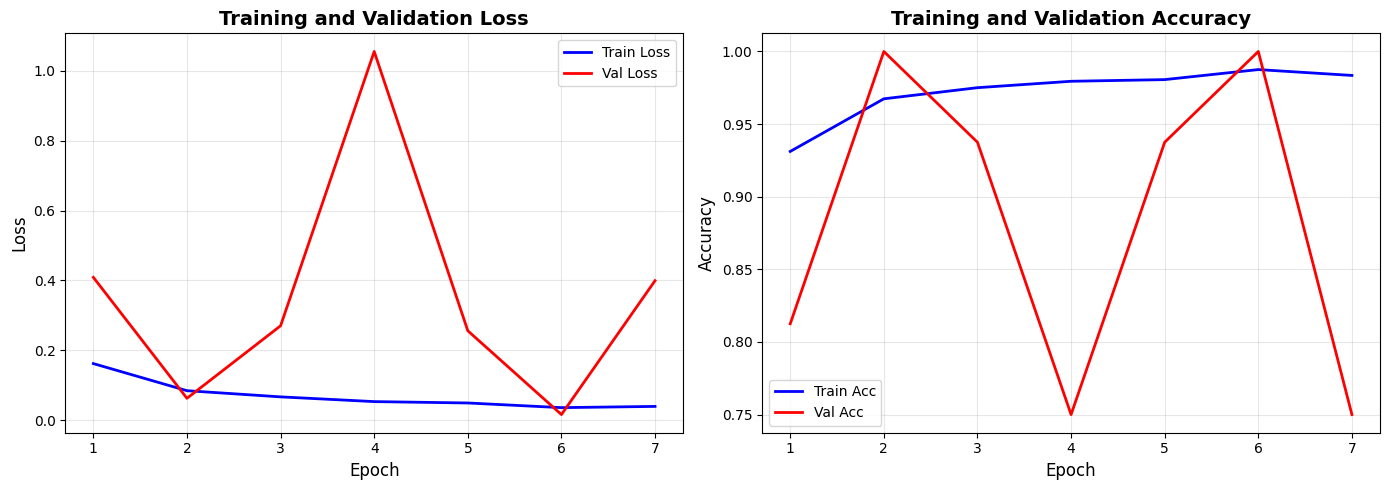

✅ Training history plotted!


In [ ]:
# ============================================
# CELL 9: Plot Training History
# ============================================
def plot_training_history(history):
    """Plot training curves"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Accuracy plot
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    wandb.log({"training_history": wandb.Image(fig)})
    plt.savefig(os.path.join(RESULTS_DIR, 'training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)
print("✅ Training history plotted!")

In [ ]:
# ============================================
# CELL 10: Load Best Model & Evaluate on Test Set
# ============================================
# Load best checkpoint
checkpoint_path = os.path.join(MODELS_DIR, 'best_centralized_model.pth')
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"   Validation Accuracy: {checkpoint['val_acc']:.4f}")

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = validate(
    model, test_loader, criterion, device
)

print(f"\n📊 Test Set Results:")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f}")

✅ Loaded best model from epoch 2
   Validation Accuracy: 1.0000


Validation: 100%|██████████| 10/10 [02:03<00:00, 12.34s/it]


📊 Test Set Results:
   Test Loss: 0.5019
   Test Accuracy: 0.8221


In [ ]:
# ============================================
# CELL 11: Calculate Detailed Metrics
# ============================================
# Calculate all metrics
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
roc_auc = roc_auc_score(test_labels, test_probs)

metrics = {
    'test_accuracy': test_acc,
    'test_loss': test_loss,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'roc_auc': roc_auc
}

print("\n" + "="*60)
print("📊 FINAL TEST METRICS")
print("="*60)
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*60)

# Log to WandB
wandb.log(metrics)


📊 FINAL TEST METRICS
Accuracy:  0.8221 (82.21%)
Precision: 0.7853 (78.53%)
Recall:    0.9846 (98.46%)
F1-Score:  0.8737
ROC-AUC:   0.9586


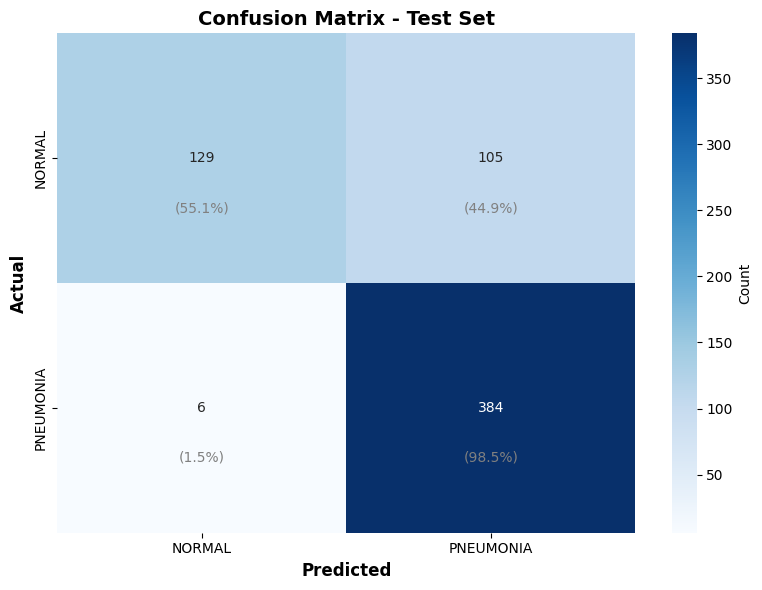


✅ Confusion Matrix:
[[129 105]
 [  6 384]]


In [ ]:
# ============================================
# CELL 12: Confusion Matrix
# ============================================
def plot_confusion_matrix(y_true, y_pred, classes=['NORMAL', 'PNEUMONIA']):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count'})

    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')

    # Add percentages
    for i in range(len(classes)):
        for j in range(len(classes)):
            percentage = cm[i, j] / cm[i].sum() * 100
            ax.text(j+0.5, i+0.7, f'({percentage:.1f}%)',
                   ha='center', va='center', fontsize=10, color='gray')

    plt.tight_layout()
    wandb.log({"confusion_matrix": wandb.Image(fig)})
    plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()

    return cm

cm = plot_confusion_matrix(test_labels, test_preds)
print("\n✅ Confusion Matrix:")
print(cm)

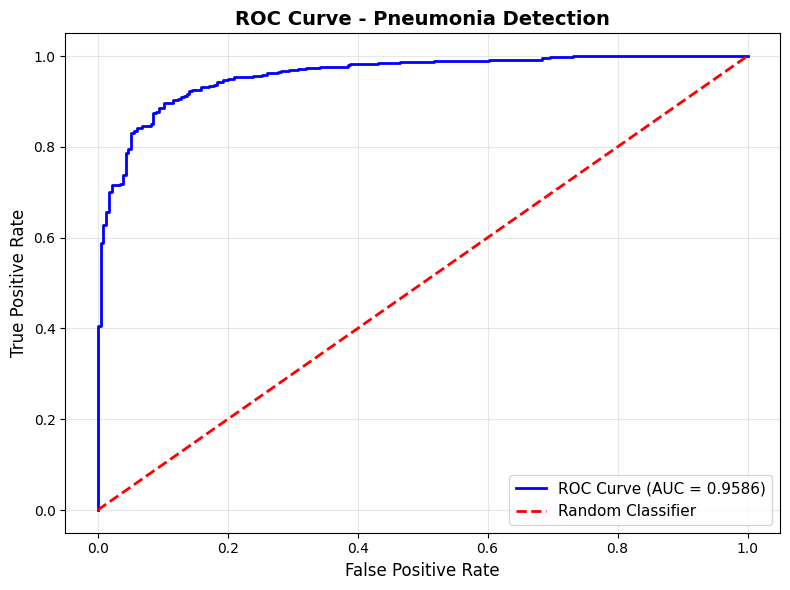

✅ ROC Curve plotted!


In [ ]:
# ============================================
# CELL 13: ROC Curve
# ============================================
def plot_roc_curve(y_true, y_probs):
    """Plot ROC curve"""
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    roc_auc = roc_auc_score(y_true, y_probs)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Random Classifier')

    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('ROC Curve - Pneumonia Detection', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    wandb.log({"roc_curve": wandb.Image(fig)})
    plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()

plot_roc_curve(test_labels, test_probs)
print("✅ ROC Curve plotted!")

In [ ]:
# ============================================
# CELL 14: Save Final Results & Summary
# ============================================
# Compile full results
results = {
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "week": 1,
    "day": 5,
    "milestone": "Centralized Baseline Training Complete",
    "model": {
        "architecture": "EfficientNetB0",
        "pretrained": True,
        "total_parameters": sum(p.numel() for p in model.parameters()),
        "trainable_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad)
    },
    "training": {
        "epochs_trained": len(history['train_loss']),
        "best_epoch": checkpoint['epoch'] + 1,
        "batch_size": config.batch_size,
        "learning_rate": config.learning_rate,
        "optimizer": "Adam",
        "scheduler": "ReduceLROnPlateau"
    },
    "metrics": {
        "test_accuracy": float(test_acc),
        "test_loss": float(test_loss),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc)
    },
    "confusion_matrix": cm.tolist(),
    "dataset_sizes": {
        "train": len(train_dataset),
        "val": len(val_dataset),
        "test": len(test_dataset)
    },
    "artifacts": {
        "model_checkpoint": "models/best_centralized_model.pth",
        "training_history": "results/training_history.png",
        "confusion_matrix": "results/confusion_matrix.png",
        "roc_curve": "results/roc_curve.png"
    }
}

# Save results
results_path = os.path.join(RESULTS_DIR, 'day5_baseline_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

# Create summary table for WandB
summary_table = wandb.Table(
    columns=["Metric", "Value"],
    data=[
        ["Model", "EfficientNetB0"],
        ["Test Accuracy", f"{test_acc*100:.2f}%"],
        ["Precision", f"{precision*100:.2f}%"],
        ["Recall", f"{recall*100:.2f}%"],
        ["F1-Score", f"{f1:.4f}"],
        ["ROC-AUC", f"{roc_auc:.4f}"],
        ["Epochs Trained", str(len(history['train_loss']))],
        ["Parameters", f"{sum(p.numel() for p in model.parameters()):,}"]
    ]
)
wandb.log({"baseline_summary": summary_table})

print("\n" + "="*60)
print("🎉 DAY 5 COMPLETE - CENTRALIZED BASELINE TRAINED!")
print("="*60)
print(f"\n📊 Final Metrics:")
print(f"   Accuracy:  {test_acc*100:.2f}%")
print(f"   Precision: {precision*100:.2f}%")
print(f"   Recall:    {recall*100:.2f}%")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")
print(f"\n💾 Model saved: {checkpoint_path}")
print(f"📄 Results saved: {results_path}")
print(f"\n✅ Week 1 COMPLETE!")
print(f"✅ Next: Week 2 - Federated Learning Implementation")
print("="*60)

wandb.finish()


🎉 DAY 5 COMPLETE - CENTRALIZED BASELINE TRAINED!

📊 Final Metrics:
   Accuracy:  82.21%
   Precision: 78.53%
   Recall:    98.46%
   F1-Score:  0.8737
   ROC-AUC:   0.9586

💾 Model saved: /content/drive/MyDrive/FL-Pneumonia-Detection/models/best_centralized_model.pth
📄 Results saved: /content/drive/MyDrive/FL-Pneumonia-Detection/results/day5_baseline_results.json

✅ Week 1 COMPLETE!
✅ Next: Week 2 - Federated Learning Implementation


epoch,▁▂▃▅▆▇█
f1_score,▁
learning_rate,▁▁▁▁▁▁▁
precision,▁
recall,▁
roc_auc,▁
test_accuracy,▁
test_loss,▁
train_acc,▁▆▆▇▇██
train_loss,█▄▃▂▂▁▁
+2,...
